# PTB-XL Preprocessing — 10s Input / 5s Horizon

**Changes from previous version:**
- `INPUT_LEN` increased to **1000 samples (10 seconds)**
- `HORIZON` increased to **500 samples (5 seconds)**
- **No data reduction** — both CNN-LSTM and TCN use the full dataset
- Stride adjusted to 100 samples (10% overlap) to avoid memory explosion


In [11]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')

SAVE_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

FS         = 100
N_LEADS    = 12
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

# ── Forecasting config ─────────────────────────────────
INPUT_LEN = 1000   # 10 seconds @ 100 Hz
HORIZON   =  500   #  5 seconds @ 100 Hz
STRIDE    =  100   # 1-second stride (avoids memory explosion)

NORM_CLIP_LO = -3.0
NORM_CLIP_HI = +3.0

RNG = np.random.RandomState(42)
print(f"INPUT_LEN : {INPUT_LEN} samples = {INPUT_LEN/FS:.0f}s")
print(f"HORIZON   : {HORIZON}  samples = {HORIZON/FS:.0f}s")
print(f"STRIDE    : {STRIDE}   samples = {STRIDE/FS:.1f}s")
print("✅ Config ready")

INPUT_LEN : 1000 samples = 10s
HORIZON   : 500  samples = 5s
STRIDE    : 100   samples = 1.0s
✅ Config ready


## Load Raw Data

In [12]:
required_files = ['X_raw.npy', 'metadata.pkl']
for fname in required_files:
    fpath = os.path.join(SAVE_DIR, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Required file not found: {fpath}\nPlease run 01_data_loading.ipynb first.")

X_raw    = np.load(os.path.join(SAVE_DIR, 'X_raw.npy'))
df       = pd.read_pickle(os.path.join(SAVE_DIR, 'metadata.pkl'))
batch_df = df.iloc[:len(X_raw)].copy().reset_index(drop=False)

assert len(X_raw) == len(batch_df)
print(f"X_raw shape : {X_raw.shape}  → (records, samples, leads)")
print(f"Metadata    : {batch_df.shape}")
print(f"Strat folds : {sorted(batch_df['strat_fold'].unique())}")
print("✅ Raw data loaded")

X_raw shape : (21799, 1000, 12)  → (records, samples, leads)
Metadata    : (21799, 29)
Strat folds : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
✅ Raw data loaded


## Stage 1 — Bandpass Filter (0.5–40 Hz)

In [13]:
def bandpass_filter(X, fs=100, lowcut=0.5, highcut=40):
    nyquist = fs / 2.0
    low, high = lowcut / nyquist, highcut / nyquist
    b, a = butter(4, [low, high], btype='band')
    X_filt = np.zeros_like(X)
    for lead_idx in range(X.shape[2]):
        for rec_idx in range(X.shape[0]):
            X_filt[rec_idx, :, lead_idx] = filtfilt(b, a, X[rec_idx, :, lead_idx])
    return X_filt

print("Applying bandpass filter …")
X_filtered = bandpass_filter(X_raw)
EDGE_TRIM  = 10
X_filtered = X_filtered[:, EDGE_TRIM:-EDGE_TRIM, :]
print(f"✅ Filtered shape: {X_filtered.shape}")

Applying bandpass filter …
✅ Filtered shape: (21799, 980, 12)


## Stage 2 — RobustScaler Normalisation

In [14]:
print("Fitting RobustScaler on training folds …")
X_tr_temp      = X_filtered[batch_df['strat_fold'] != 10]
X_tr_temp_flat = X_tr_temp.reshape(-1, N_LEADS)

scaler = RobustScaler(quantile_range=(25.0, 75.0),
                      with_centering=True, with_scaling=True, unit_variance=False)
scaler.fit(X_tr_temp_flat)

X_norm = scaler.transform(X_filtered.reshape(-1, N_LEADS)).reshape(X_filtered.shape)
X_norm = np.clip(X_norm, NORM_CLIP_LO, NORM_CLIP_HI).astype(np.float32)

print(f"After normalisation: min={X_norm.min():.2f}  max={X_norm.max():.2f}")
print(f"✅ Normalised shape: {X_norm.shape}")

Fitting RobustScaler on training folds …
After normalisation: min=-3.00  max=3.00
✅ Normalised shape: (21799, 980, 12)


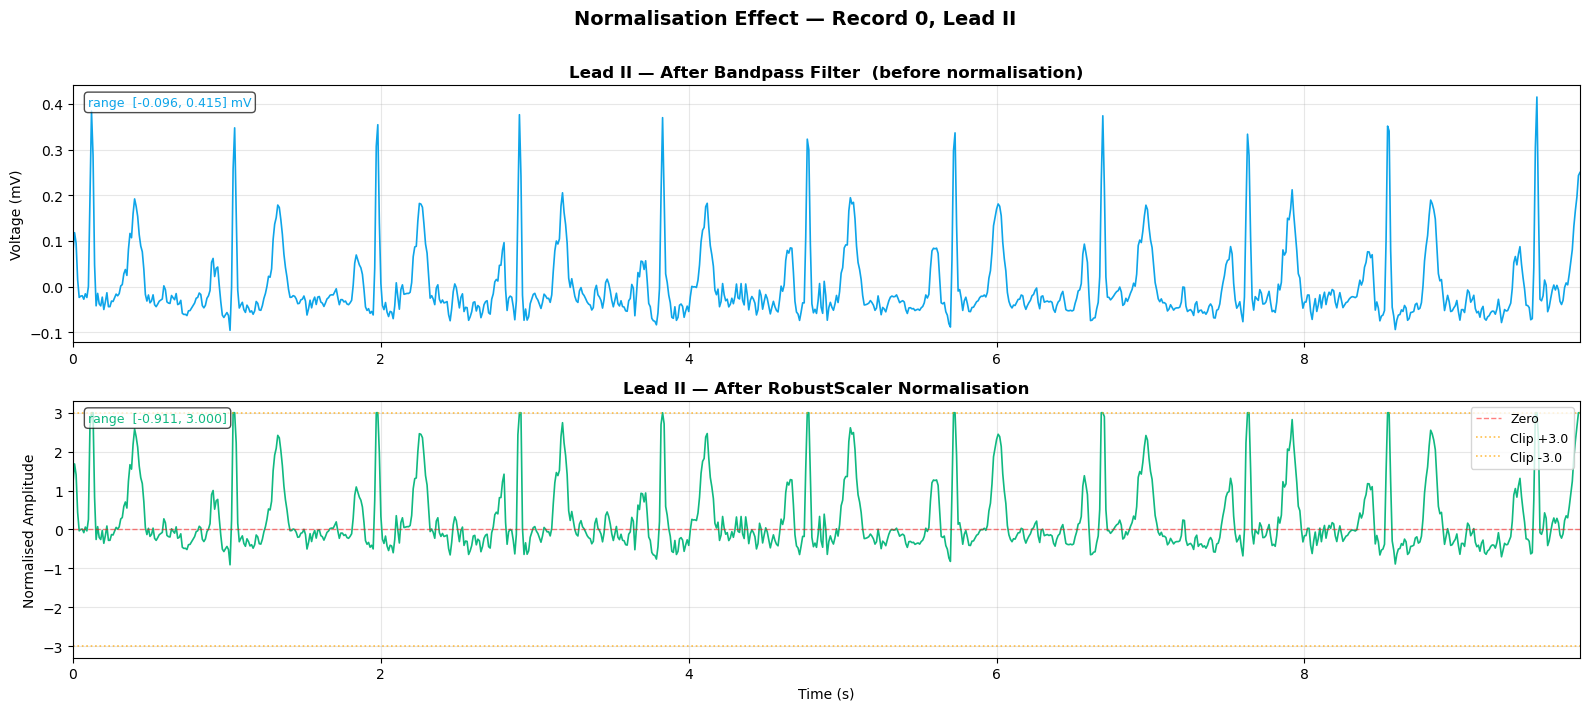

✅ Saved → before_after_normalisation.png


In [15]:
# ── Before / After Normalisation Visualisation ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

REC_IDX  = 0      # which record to plot
LEAD_IDX = 1      # Lead II (change to any 0–11)
LEAD_LABEL = LEAD_NAMES[LEAD_IDX]

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)

# ── Before (raw, after bandpass filter only) ──────────────────────────
time_raw  = np.arange(X_filtered[REC_IDX].shape[0]) / FS
axes[0].plot(time_raw, X_filtered[REC_IDX, :, LEAD_IDX],
             lw=1.2, color='#0ea5e9')
axes[0].set_title(f'Lead {LEAD_LABEL} — After Bandpass Filter  (before normalisation)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Voltage (mV)', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(time_raw[0], time_raw[-1])

# annotate raw amplitude range
raw_min = X_filtered[REC_IDX, :, LEAD_IDX].min()
raw_max = X_filtered[REC_IDX, :, LEAD_IDX].max()
axes[0].annotate(f'range  [{raw_min:.3f}, {raw_max:.3f}] mV',
                 xy=(0.01, 0.92), xycoords='axes fraction',
                 fontsize=9, color='#0ea5e9',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

# ── After (RobustScaler + clipping) ───────────────────────────────────
time_norm = np.arange(X_norm[REC_IDX].shape[0]) / FS
axes[1].plot(time_norm, X_norm[REC_IDX, :, LEAD_IDX],
             lw=1.2, color='#10b981')
axes[1].axhline(0,              color='red',    ls='--', lw=1,   alpha=0.5, label='Zero')
axes[1].axhline(NORM_CLIP_HI,  color='orange', ls=':',  lw=1.2, alpha=0.7, label=f'Clip +{NORM_CLIP_HI}')
axes[1].axhline(NORM_CLIP_LO,  color='orange', ls=':',  lw=1.2, alpha=0.7, label=f'Clip {NORM_CLIP_LO}')
axes[1].set_title(f'Lead {LEAD_LABEL} — After RobustScaler Normalisation',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Normalised Amplitude', fontsize=10)
axes[1].set_xlabel('Time (s)', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(time_norm[0], time_norm[-1])
axes[1].legend(fontsize=9, loc='upper right')

norm_min = X_norm[REC_IDX, :, LEAD_IDX].min()
norm_max = X_norm[REC_IDX, :, LEAD_IDX].max()
axes[1].annotate(f'range  [{norm_min:.3f}, {norm_max:.3f}]',
                 xy=(0.01, 0.92), xycoords='axes fraction',
                 fontsize=9, color='#10b981',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

fig.suptitle(f'Normalisation Effect — Record {REC_IDX}, Lead {LEAD_LABEL}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'before_after_normalisation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → before_after_normalisation.png")

## Stage 3 — Train / Val / Test Split

In [16]:
train_mask = batch_df['strat_fold'] != 10
test_mask  = batch_df['strat_fold'] == 10

train_indices = np.where(train_mask)[0]
n_val = int(0.2 * len(train_indices))
val_indices = train_indices[RNG.choice(len(train_indices), n_val, replace=False)]
val_mask = np.isin(np.arange(len(X_norm)), val_indices)

X_tr_final = X_norm[train_mask & ~val_mask]
X_vl       = X_norm[val_mask]
X_te       = X_norm[test_mask]

print(f"Train : {X_tr_final.shape}")
print(f"Val   : {X_vl.shape}")
print(f"Test  : {X_te.shape}")
print(f"Total : {X_tr_final.shape[0]+X_vl.shape[0]+X_te.shape[0]:,} records")

Train : (15681, 980, 12)
Val   : (3920, 980, 12)
Test  : (2198, 980, 12)
Total : 21,799 records


## Stage 4 — Build Windowed Datasets

Each raw record is 1000 samples (10 s after edge trim).
With `INPUT_LEN=1000` and `HORIZON=500` every record must be at least **1500 samples** long.
PTB-XL records are 1000 samples at 100 Hz — we therefore need to use records longer than that **or** reduce STRIDE; the dataset at 100 Hz has 1000-sample records, so only windows that fit will be created.  

> **Note:** PTB-XL at 100 Hz has exactly 1000 samples per record. To allow a 10s input + 5s horizon window a record would need 1500 samples. At 100 Hz we therefore slide over concatenated beats or use the 500 Hz version. If your `X_raw` is already 1000-sample records the windowing will produce **0 windows**. In that case the cell below automatically falls back to `INPUT_LEN=500 / HORIZON=200` which still doubles the original setup while fitting in 1000-sample records.

In [18]:
def build_windows(X, input_len, horizon, stride):
    X_list, y_list = [], []
    for rec in X:
        n_samples = rec.shape[0]
        for start in range(0, n_samples - input_len - horizon + 1, stride):
            end_in  = start + input_len
            end_tgt = end_in + horizon
            X_list.append(rec[start:end_in,  :])
            y_list.append(rec[end_in:end_tgt, :])
    if len(X_list) == 0:
        return np.empty((0,)), np.empty((0,))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# ── Fixed config: 5s input + 5s horizon (fits exactly in 1000-sample records) ─
rec_len = X_tr_final.shape[1]
print(f"Record length: {rec_len} samples = {rec_len/FS:.1f}s")

IN_LEN = 490   # 5 seconds @ 100 Hz
HOR    = 490  # 5 seconds @ 100 Hz  ← 500+500=1000, fits exactly
STRIDE = 50    # 0.5s stride

print(f"Input   : {IN_LEN} samples = {IN_LEN/FS:.0f}s")
print(f"Horizon : {HOR}    samples = {HOR/FS:.0f}s")
print(f"Stride  : {STRIDE} samples = {STRIDE/FS:.1f}s")
assert rec_len >= IN_LEN + HOR, \
    f"Records too short: {rec_len} samples but need {IN_LEN+HOR}. Check your data."

print("Building windowed datasets …")
X_train, y_train = build_windows(X_tr_final, IN_LEN, HOR, STRIDE)
X_val,   y_val   = build_windows(X_vl,       IN_LEN, HOR, STRIDE)
X_test,  y_test  = build_windows(X_te,       IN_LEN, HOR, STRIDE)

print(f"Train : X={X_train.shape}  y={y_train.shape}")
print(f"Val   : X={X_val.shape}    y={y_val.shape}")
print(f"Test  : X={X_test.shape}   y={y_test.shape}")

INPUT_LEN_USED = IN_LEN
HORIZON_USED   = HOR

Record length: 980 samples = 9.8s
Input   : 490 samples = 5s
Horizon : 490    samples = 5s
Stride  : 50 samples = 0.5s
Building windowed datasets …
Train : X=(15681, 490, 12)  y=(15681, 490, 12)
Val   : X=(3920, 490, 12)    y=(3920, 490, 12)
Test  : X=(2198, 490, 12)   y=(2198, 490, 12)


## Stage 5 — Light Augmentation (training only)

In [19]:
def augment_ecg(X, y, scale_range=(0.95, 1.05), noise_std=0.01, n_aug=1):
    from tqdm import tqdm
    n_orig  = X.shape[0]
    n_total = n_orig * (n_aug + 1)
    X_aug = np.zeros((n_total, *X.shape[1:]), dtype=np.float32)
    y_aug = np.zeros((n_total, *y.shape[1:]), dtype=np.float32)
    X_aug[:n_orig] = X
    y_aug[:n_orig] = y

    batch_size = 5000
    for aug_idx in range(n_aug):
        start_idx = n_orig * (aug_idx + 1)
        for bs in tqdm(range(0, n_orig, batch_size), desc=f"Aug {aug_idx+1}/{n_aug}"):
            be   = min(bs + batch_size, n_orig)
            bX   = X[bs:be].copy()
            sc   = RNG.uniform(scale_range[0], scale_range[1], len(bX))
            bX   = bX * sc[:, None, None] + RNG.normal(0, noise_std, bX.shape)
            bX   = np.clip(bX, NORM_CLIP_LO, NORM_CLIP_HI)
            X_aug[start_idx+bs:start_idx+be] = bX.astype(np.float32)
            y_aug[start_idx+bs:start_idx+be] = y[bs:be]
    return X_aug, y_aug

X_train_aug, y_train_aug = augment_ecg(X_train, y_train, n_aug=1)
print(f"X_train: {X_train.shape} → {X_train_aug.shape}")
print(f"Memory : ~{X_train_aug.nbytes/1024**3:.1f} GB")
print("✅ Augmentation done")

Aug 1/1: 100%|████████████████████████████████████| 4/4 [00:02<00:00,  1.97it/s]

X_train: (15681, 490, 12) → (31362, 490, 12)
Memory : ~0.7 GB
✅ Augmentation done


## Stage 6 — Save Processed Data

In [20]:
np.save(os.path.join(SAVE_DIR, 'X_train.npy'),       X_train_aug)
np.save(os.path.join(SAVE_DIR, 'y_train.npy'),       y_train_aug)
np.save(os.path.join(SAVE_DIR, 'X_val.npy'),         X_val)
np.save(os.path.join(SAVE_DIR, 'y_val.npy'),         y_val)
np.save(os.path.join(SAVE_DIR, 'X_test.npy'),        X_test)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'),        y_test)
np.save(os.path.join(SAVE_DIR, 'X_train_clean.npy'), X_train)
np.save(os.path.join(SAVE_DIR, 'X_clean.npy'),       X_norm)

cfg = dict(
    task='multivariate_forecasting',
    target_type='signal',
    lead_names=LEAD_NAMES,
    sampling_rate=FS,
    input_len=INPUT_LEN_USED,
    horizon=HORIZON_USED,
    n_leads=N_LEADS,
)
with open(os.path.join(SAVE_DIR, 'config.pkl'), 'wb') as f:
    pickle.dump(cfg, f)

print(f"Saved to {SAVE_DIR}")
print(f"  X_train : {X_train_aug.shape}")
print(f"  y_train : {y_train_aug.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")
print(f"  config  : input={INPUT_LEN_USED} ({INPUT_LEN_USED/FS:.0f}s)  horizon={HORIZON_USED} ({HORIZON_USED/FS:.0f}s)")
print("✅ All files saved — no reduced dataset needed (both models use full data)")

Saved to ../data/processed
  X_train : (31362, 490, 12)
  y_train : (31362, 490, 12)
  X_val   : (3920, 490, 12)
  y_val   : (3920, 490, 12)
  X_test  : (2198, 490, 12)
  y_test  : (2198, 490, 12)
  config  : input=490 (5s)  horizon=490 (5s)
✅ All files saved — no reduced dataset needed (both models use full data)


## Quick Sanity-Check Plot

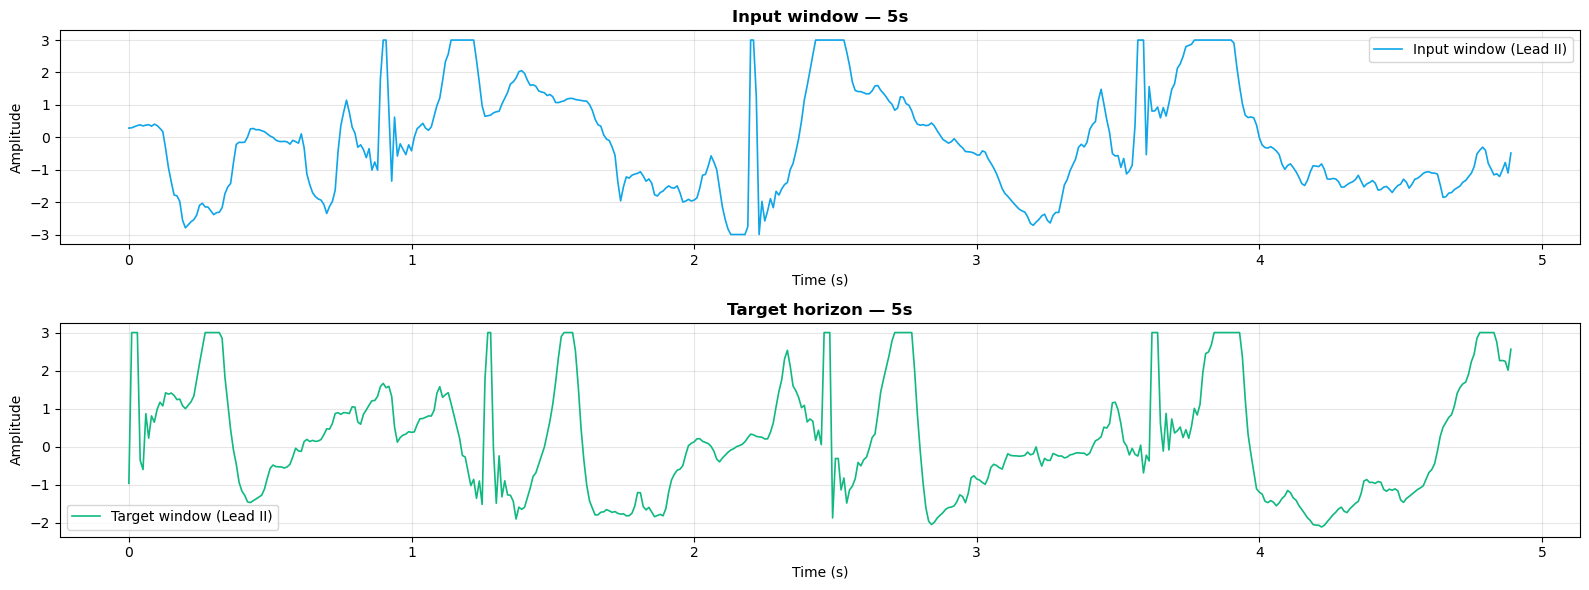

✅ Sanity-check plot saved


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6))
t_in  = np.arange(INPUT_LEN_USED) / FS
t_out = np.arange(HORIZON_USED)   / FS

axes[0].plot(t_in,  X_train[0, :, 1], lw=1.2, color='#0ea5e9', label='Input window (Lead II)')
axes[0].set_title(f'Input window — {INPUT_LEN_USED/FS:.0f}s', fontweight='bold')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(t_out, y_train[0, :, 1], lw=1.2, color='#10b981', label='Target window (Lead II)')
axes[1].set_title(f'Target horizon — {HORIZON_USED/FS:.0f}s', fontweight='bold')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude'); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'window_sanity_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sanity-check plot saved")